In [ ]:
# pip install ipykernel

In [2]:
# pip install pandas-datareader

In [9]:
# %pip install pyarrow

In [1]:
import sys
print(sys.executable)

c:\Users\harsh\NCI\Sem2\Practicum\xai-throughput-optimizer\xai-asynch-env\Scripts\python.exe


In [2]:
import pip
print(pip.__version__)

26.1.2


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import joblib

import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix

os.makedirs('../models', exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment successfully initialized.")

Environment successfully initialized.


In [ ]:
file_path = '../data/accepted_2007_to_2018Q4.csv'
parquet_file_path = '../data/accepted_2007_to_2018Q4_pruned.parquet'

# 1. The Full Kill List (48 Columns)
columns_to_drop = [
    'id', 'member_id', 'url', 'desc', 'emp_title', 'title',
    'funded_amnt', 'funded_amnt_inv', 
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
    'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
    'last_fico_range_high', 'last_fico_range_low',
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date',
    'payment_plan_start_date', 'hardship_length', 'hardship_dpd', 'hardship_loan_status',
    'orig_projected_additional_accrued_interest', 'hardship_payoff_balance_amount',
    'hardship_last_payment_amount', 'debt_settlement_flag', 'debt_settlement_flag_date',
    'settlement_status', 'settlement_date', 'settlement_amount', 'settlement_percentage',
    'settlement_term', 'pymnt_plan', 'initial_list_status', 'disbursement_method'
]

print("Initiating One-Pass ETL and Audit Pipeline...")
start_time = time.time()

writer = None
fixed_schema = None

# Trackers for the Audit Report
original_row_count = 0
original_col_count = 0

print(f"Streaming CSV and converting to {parquet_file_path}...")

# 2. Stream, Audit, and Convert
for chunk in pd.read_csv(file_path, chunksize=100000, dtype=str, low_memory=False):
    
    # Capture original metrics from the very first chunk
    if original_col_count == 0:
        original_col_count = len(chunk.columns)
        
    # Keep a running tally of original rows
    original_row_count += len(chunk)
    
    # Drop leakage columns
    chunk = chunk.drop(columns=columns_to_drop, errors='ignore')
    
    # Force the strict string schema on the first chunk to prevent PyArrow 'null' errors
    if writer is None:
        fields = [pa.field(col, pa.string()) for col in chunk.columns]
        fixed_schema = pa.schema(fields)
        writer = pq.ParquetWriter(parquet_file_path, fixed_schema)
    
    # Convert Pandas chunk using dictated schema
    table = pa.Table.from_pandas(chunk, schema=fixed_schema)
    
    # Write the chunk
    writer.write_table(table)

# Close the file connection
if writer:
    writer.close()

# 3. Load the final Parquet file to verify its state
print("Loading final Parquet file into memory for verification...")
pq_df = pd.read_parquet(parquet_file_path)
final_row_count, final_col_count = pq_df.shape

# 4. Generate the Audit Report
print("\n" + "="*45)
print(" 📊 ETL PIPELINE AUDIT REPORT")
print("="*45)
print(f"Original CSV Rows:      {original_row_count:,}")
print(f"Final Parquet Rows:     {final_row_count:,}")
print(f"Row Difference:         {original_row_count - final_row_count:,} (Should be 0)")
print("-" * 45)
print(f"Original Columns:       {original_col_count}")
print(f"Final Columns:          {final_col_count}")
print(f"Columns Dropped:        {original_col_count - final_col_count}")
print("="*45)
print(f"Pipeline completed in {time.time() - start_time:.2f} seconds.")

Initiating One-Pass ETL and Audit Pipeline...
Streaming CSV and converting to ../data/accepted_2007_to_2018Q4_pruned.parquet...
Loading final Parquet file into memory for verification...

 📊 ETL PIPELINE AUDIT REPORT
Original CSV Rows:      2,260,701
Final Parquet Rows:     2,260,701
Row Difference:         0 (Should be 0)
---------------------------------------------
Original Columns:       151
Final Columns:          103
Columns Dropped:        48
Pipeline completed in 159.15 seconds.


In [ ]:
start_time = time.time()

print("Loading pruned Parquet file...")
# Load the 103-column dataset
df = pd.read_parquet('../data/accepted_2007_to_2018Q4_pruned.parquet')

# Capture initial state for the Audit Report
initial_rows, initial_cols = df.shape

# 1. Standardize the Main Dataset Date
print("Standardizing loan issue dates...")
# Lending Club 'issue_d' is formatted like "Dec-2015". Convert to Year-Month period.
df['issue_d_period'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce').dt.to_period('M')

# 2. Memory-Safe Dictionary Processor
def process_fred_to_dict(file_path):
    macro_df = pd.read_csv(file_path)
    
    # Dynamically grab the name of the second column (UNRATE, CPIAUCSL, FEDFUNDS)
    ticker_column = macro_df.columns[1]
    
    # Convert FRED's 'observation_date' string to the matching Year-Month period
    macro_df['date_period'] = pd.to_datetime(macro_df['observation_date']).dt.to_period('M')
    
    # Convert directly into a fast, lightweight Python dictionary: {Period('2007-01'): 4.6}
    return dict(zip(macro_df['date_period'], macro_df[ticker_column]))

# 3. Load the Macroeconomic CSVs as Dictionaries
print("Loading FRED macroeconomic CSVs as memory-safe dictionaries...")
unemployment_dict = process_fred_to_dict('../data/UNRATE.csv')
cpi_dict = process_fred_to_dict('../data/CPIAUCSL.csv')
fed_funds_dict = process_fred_to_dict('../data/FEDFUNDS.csv')

# 4. Perform the RAM-Safe Mapping (Bypassing pd.merge)
print("Mapping macroeconomic indicators into main dataset...")
df['macro_unemployment_rate'] = df['issue_d_period'].map(unemployment_dict)
df['macro_cpi'] = df['issue_d_period'].map(cpi_dict)
df['macro_fed_funds'] = df['issue_d_period'].map(fed_funds_dict)

# 5. Clean up temporary date keys and the original text-based issue_d column
df = df.drop(columns=['issue_d', 'issue_d_period'])

# Capture final state
final_rows, final_cols = df.shape

# 6. Generate the Comprehensive Audit Report
print("\n" + "="*45)
print(" 📊 MERGE PIPELINE AUDIT REPORT")
print("="*45)
print(f"Initial Rows:           {initial_rows:,}")
print(f"Final Rows:             {final_rows:,}")
print(f"Row Difference:         {final_rows - initial_rows:,} (Should be 0)")
print("-" * 45)
print(f"Initial Columns:        {initial_cols}")
print(f"Final Columns:          {final_cols}")
print(f"Columns Added:          {final_cols - initial_cols} (Should be 2 net: +3 added, -1 dropped)")
print("="*45)
print(f"Mapping completed in {time.time() - start_time:.2f} seconds.")

# Verify the newly appended features are populated
print("\nSample of appended macroeconomic data:")
print(df[['macro_unemployment_rate', 'macro_cpi', 'macro_fed_funds']].head(5))

# 7. Save the newly merged dataset back to disk
output_parquet_path = '../data/accepted_2007_to_2018Q4_merged.parquet'
print(f"\nSaving merged dataset to {output_parquet_path}...")

# to_parquet automatically uses PyArrow under the hood to preserve the strict string schema
df.to_parquet(output_parquet_path, index=False)

print("Save complete! Pipeline state locked.")

Loading pruned Parquet file...
Standardizing loan issue dates...
Loading FRED macroeconomic CSVs as memory-safe dictionaries...
Mapping macroeconomic indicators into main dataset...

 📊 MERGE PIPELINE AUDIT REPORT
Initial Rows:           2,260,701
Final Rows:             2,260,701
Row Difference:         0 (Should be 0)
---------------------------------------------
Initial Columns:        103
Final Columns:          105
Columns Added:          2 (Should be 2 net: +3 added, -1 dropped)
Mapping completed in 18.85 seconds.

Sample of appended macroeconomic data:
   macro_unemployment_rate  macro_cpi  macro_fed_funds
0                      5.0    237.761             0.24
1                      5.0    237.761             0.24
2                      5.0    237.761             0.24
3                      5.0    237.761             0.24
4                      5.0    237.761             0.24

Saving merged dataset to ../data/accepted_2007_to_2018Q4_merged.parquet...
Save complete! Pipeline stat

In [ ]:
print("Loading merged Parquet file for NaN Analysis...")
df = pd.read_parquet('../data/accepted_2007_to_2018Q4_merged.parquet')

print("Calculating missing value percentages...\n")

# 1. Calculate the percentage of missing values per column
nan_percentages = (df.isna().sum() / len(df)) * 100

# 2. Filter to only show columns that actually have missing data, and sort them descending
missing_data = nan_percentages[nan_percentages > 0].sort_values(ascending=False)

# 3. Format the output into a clean, readable DataFrame
audit_df = pd.DataFrame({
    'Feature': missing_data.index,
    'Missing_Percentage': missing_data.values.round(2)
})

print("="*50)
print(" 🚨 MISSING DATA AUDIT REPORT 🚨")
print("="*50)
print(f"Total Columns Evaluated: {df.shape[1]}")
print(f"Columns with Missing Data: {len(audit_df)}")
print("-" * 50)

# 4. Display the results categorized by severity
print("\n🔴 SEVERE MISSING DATA (> 50% NaN):")
severe = audit_df[audit_df['Missing_Percentage'] > 50]
print(severe.to_string(index=False) if not severe.empty else "None")

print("\n🟡 MODERATE MISSING DATA (10% - 50% NaN):")
moderate = audit_df[(audit_df['Missing_Percentage'] > 10) & (audit_df['Missing_Percentage'] <= 50)]
print(moderate.to_string(index=False) if not moderate.empty else "None")

print("\n🟢 MINOR MISSING DATA (< 10% NaN):")
minor = audit_df[audit_df['Missing_Percentage'] <= 10]
# Just show the top 10 minor ones to save screen space
print(minor.head(10).to_string(index=False) if not minor.empty else "None")

Loading merged Parquet file for NaN Analysis...
Calculating missing value percentages...

 🚨 MISSING DATA AUDIT REPORT 🚨
Total Columns Evaluated: 105
Columns with Missing Data: 105
--------------------------------------------------

🔴 SEVERE MISSING DATA (> 50% NaN):
                            Feature  Missing_Percentage
sec_app_mths_since_last_major_derog               98.41
                 sec_app_revol_util               95.30
                    revol_bal_joint               95.22
              sec_app_num_rev_accts               95.22
                sec_app_open_act_il               95.22
                   sec_app_mort_acc               95.22
           sec_app_earliest_cr_line               95.22
            sec_app_fico_range_high               95.22
                   sec_app_open_acc               95.22
             sec_app_fico_range_low               95.22
             sec_app_inq_last_6mths               95.22
   sec_app_chargeoff_within_12_mths               95.22
 sec

Loading merged Parquet file for Visual EDA...
Calculating metrics...


C:\Users\harsh\AppData\Local\Temp\ipykernel_30752\1573271757.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=status_counts.values, y=status_counts.index, palette='magma')
C:\Users\harsh\AppData\Local\Temp\ipykernel_30752\1573271757.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_cardinality.values, y=cat_cardinality.index, palette='viridis')


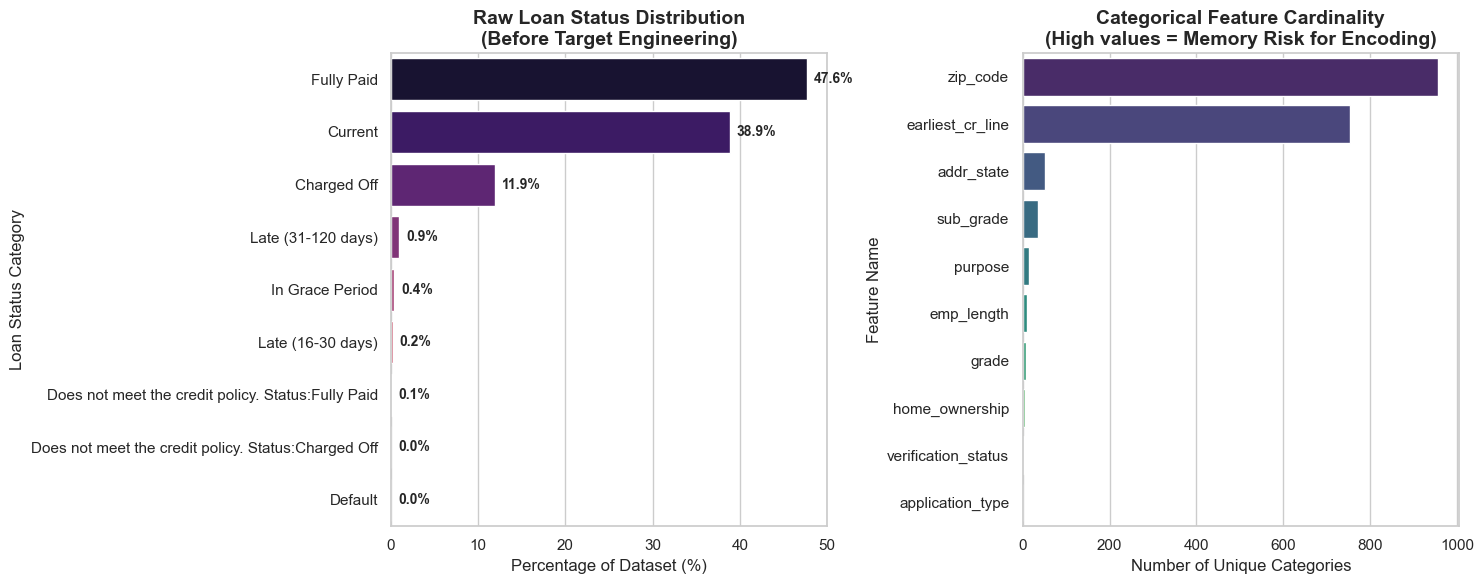


 📊 EDA SUMMARY METRICS 📊
Total Rows: 2,260,701
Top 3 Loan Status Categories:
 - Fully Paid: 1,076,751 (47.6%)
 - Current: 878,317 (38.9%)
 - Charged Off: 268,559 (11.9%)


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading merged Parquet file for Visual EDA...")
df = pd.read_parquet('../data/accepted_2007_to_2018Q4_merged.parquet')

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

print("Calculating metrics...")

# ==========================================
# 1. LOAN STATUS CLASS BALANCE (Our future target)
# ==========================================
plt.subplot(1, 2, 1)
# Calculate percentages of the raw string categories
status_counts = df['loan_status'].value_counts(normalize=True) * 100

# Create a horizontal bar plot for readability 
ax = sns.barplot(x=status_counts.values, y=status_counts.index, palette='magma')
plt.title('Raw Loan Status Distribution\n(Before Target Engineering)', fontsize=14, fontweight='bold')
plt.xlabel('Percentage of Dataset (%)')
plt.ylabel('Loan Status Category')

# Add percentage labels
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')

# ==========================================
# 2. STRING CARDINALITY (The Danger Zones)
# ==========================================
plt.subplot(1, 2, 2)
cardinality = df.nunique().sort_values(ascending=False)

# Safely select categorical columns
categorical_cols = ['grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 
                    'purpose', 'zip_code', 'addr_state', 'earliest_cr_line', 'application_type']

# Filter to ensure we only plot columns that survived our pruning phase
existing_cat_cols = [col for col in categorical_cols if col in df.columns]
cat_cardinality = cardinality[existing_cat_cols].sort_values(ascending=False)

sns.barplot(x=cat_cardinality.values, y=cat_cardinality.index, palette='viridis')
plt.title('Categorical Feature Cardinality\n(High values = Memory Risk for Encoding)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Unique Categories')
plt.ylabel('Feature Name')

plt.tight_layout()
plt.show()

# Print Summary
print("\n" + "="*50)
print(" 📊 EDA SUMMARY METRICS 📊")
print("="*50)
print(f"Total Rows: {len(df):,}")
print("Top 3 Loan Status Categories:")
for status, count in df['loan_status'].value_counts().head(3).items():
    print(f" - {status}: {count:,} ({(count/len(df))*100:.1f}%)")
print("="*50)

In [7]:
import pandas as pd
import numpy as np
import time

start_time = time.time()

print("Loading merged Parquet file...")
df = pd.read_parquet('../data/accepted_2007_to_2018Q4_merged.parquet')
initial_rows = len(df)

# ==========================================
# 1. TARGET ENGINEERING
# ==========================================
print("Filtering out indeterminate loans and mapping target...")
# Keep only loans that have finished
valid_statuses = ['Fully Paid', 'Charged Off', 'Default']
df = df[df['loan_status'].isin(valid_statuses)].copy()

# Map to Binary (0 = Good, 1 = Bad)
target_mapping = {'Fully Paid': 0, 'Charged Off': 1, 'Default': 1}
df['target'] = df['loan_status'].map(target_mapping)

# Drop the original text column
df = df.drop(columns=['loan_status'])

# ==========================================
# 2. DROPPING HAZARDS & SEVERE NaNs
# ==========================================
print("Dropping high-cardinality landmines and 95%+ NaN columns...")
# High Cardinality
df = df.drop(columns=['zip_code', 'earliest_cr_line'], errors='ignore')

# The Co-Signer Trap (95%+ Missing)
severe_nan_cols = [col for col in df.columns if 'sec_app' in col or 'joint' in col]
df = df.drop(columns=severe_nan_cols, errors='ignore')

# ==========================================
# 3. DIRTY NUMERICAL STRIPPING
# ==========================================
print("Stripping text units (' months', '%') from numerical columns...")
if 'term' in df.columns:
    df['term'] = df['term'].str.replace(' months', '', regex=False)
if 'int_rate' in df.columns:
    df['int_rate'] = df['int_rate'].str.replace('%', '', regex=False)
if 'revol_util' in df.columns:
    df['revol_util'] = df['revol_util'].str.replace('%', '', regex=False)

# ==========================================
# 4. MASS TYPE CONVERSION (RAM Savior)
# ==========================================
print("Executing mass conversion to memory-efficient float32...")

# Define the true categoricals that we want to keep as strings for now
categorical_cols = ['grade', 'sub_grade', 'emp_length', 'home_ownership', 
                    'verification_status', 'purpose', 'addr_state', 'application_type']

# Everything else (except the target) is a disguised number
num_cols = [col for col in df.columns if col not in categorical_cols and col != 'target']

# Convert all strings back to numbers using float32 (uses 50% less RAM than standard float64)
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('float32')

# ==========================================
# 5. MODERATE NaN IMPUTATION (The Paradox)
# ==========================================
print("Handling delinquency paradox NaNs...")
paradox_cols = [
    'mths_since_last_delinq', 'mths_since_recent_inq', 'mths_since_last_major_derog', 
    'mths_since_last_record', 'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq'
]
for col in paradox_cols:
    if col in df.columns:
        # Fill with 999 to represent "Never" occurred
        df[col] = df[col].fillna(999.0)

# ==========================================
# 6. SAVE AND AUDIT
# ==========================================
final_rows, final_cols = df.shape

print("\n" + "="*50)
print(" 🧹 CLEANING PIPELINE AUDIT REPORT 🧹")
print("="*50)
print(f"Initial Rows:           {initial_rows:,}")
print(f"Final Rows (Closed):    {final_rows:,}")
print(f"Rows Dropped:           {initial_rows - final_rows:,} ('Current' loans removed)")
print("-" * 50)
print(f"Final Column Count:     {final_cols}")
print("="*50)
print(f"Cleaning completed in {time.time() - start_time:.2f} seconds.")

output_parquet_path = '../data/accepted_2007_to_2018Q4_cleaned.parquet'
print(f"\nSaving cleaned dataset to {output_parquet_path}...")
df.to_parquet(output_parquet_path, index=False)
print("Save complete! Dataset is mathematically sound.")

Loading merged Parquet file...
Filtering out indeterminate loans and mapping target...
Dropping high-cardinality landmines and 95%+ NaN columns...
Stripping text units (' months', '%') from numerical columns...
Executing mass conversion to memory-efficient float32...
Handling delinquency paradox NaNs...

 🧹 CLEANING PIPELINE AUDIT REPORT 🧹
Initial Rows:           2,260,701
Final Rows (Closed):    1,345,350
Rows Dropped:           915,351 ('Current' loans removed)
--------------------------------------------------
Final Column Count:     87
Cleaning completed in 69.50 seconds.

Saving cleaned dataset to ../data/accepted_2007_to_2018Q4_cleaned.parquet...
Save complete! Dataset is mathematically sound.


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import time

start_time = time.time()

print("Loading cleaned Parquet dataset...")
df = pd.read_parquet('../data/accepted_2007_to_2018Q4_cleaned.parquet')

# 1. Separate Features (X) from Target (y)
print("Separating features and target...")
y = df['target']
X = df.drop(columns=['target'])

# 2. Execute the Stratified Split (80% Train, 20% Test)
print("Executing Stratified Train/Test Split (80/20)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y  # THIS is the crucial parameter for imbalanced datasets
)

# 3. Generate the Split Audit Report
print("\n" + "="*50)
print(" ✂️ DATA SPLIT AUDIT REPORT ✂️")
print("="*50)
print(f"Total Original Rows:    {len(df):,}")
print(f"Training Set Rows:      {len(X_train):,} (80%)")
print(f"Testing Set Rows:       {len(X_test):,} (20%)")
print("-" * 50)

# Verify the Stratification worked perfectly
train_bad_ratio = (y_train.sum() / len(y_train)) * 100
test_bad_ratio = (y_test.sum() / len(y_test)) * 100

print(f"Train 'Bad Loan' Ratio: {train_bad_ratio:.2f}%")
print(f"Test 'Bad Loan' Ratio:  {test_bad_ratio:.2f}%")
print("="*50)

# 4. Save the components to disk
print("\nSaving Train and Test sets to disk...")
X_train.to_parquet('../data/X_train.parquet', index=False)
X_test.to_parquet('../data/X_test.parquet', index=False)

# Targets are just 1D arrays (Series), so we convert them to DataFrames to save as Parquet
pd.DataFrame(y_train).to_parquet('../data/y_train.parquet', index=False)
pd.DataFrame(y_test).to_parquet('../data/y_test.parquet', index=False)

print(f"Split and save completed in {time.time() - start_time:.2f} seconds.")

Loading cleaned Parquet dataset...
Separating features and target...
Executing Stratified Train/Test Split (80/20)...

 ✂️ DATA SPLIT AUDIT REPORT ✂️
Total Original Rows:    1,345,350
Training Set Rows:      1,076,280 (80%)
Testing Set Rows:       269,070 (20%)
--------------------------------------------------
Train 'Bad Loan' Ratio: 19.96%
Test 'Bad Loan' Ratio:  19.97%

Saving Train and Test sets to disk...
Split and save completed in 14.24 seconds.


In [2]:
import json

# Grab 1 raw row before any encoding or scaling happened
raw_row = X.head(1).to_dict(orient='records')[0]

# Print the clean JSON payload
print(json.dumps(raw_row, indent=2))

{
  "loan_amnt": 3600.0,
  "term": 36.0,
  "int_rate": 13.989999771118164,
  "installment": 123.02999877929688,
  "grade": "C",
  "sub_grade": "C4",
  "emp_length": "10+ years",
  "home_ownership": "MORTGAGE",
  "annual_inc": 55000.0,
  "verification_status": "Not Verified",
  "purpose": "debt_consolidation",
  "addr_state": "PA",
  "dti": 5.909999847412109,
  "delinq_2yrs": 0.0,
  "fico_range_low": 675.0,
  "fico_range_high": 679.0,
  "inq_last_6mths": 1.0,
  "mths_since_last_delinq": 30.0,
  "mths_since_last_record": 999.0,
  "open_acc": 7.0,
  "pub_rec": 0.0,
  "revol_bal": 2765.0,
  "revol_util": 29.700000762939453,
  "total_acc": 13.0,
  "collections_12_mths_ex_med": 0.0,
  "mths_since_last_major_derog": 30.0,
  "policy_code": 1.0,
  "application_type": "Individual",
  "acc_now_delinq": 0.0,
  "tot_coll_amt": 722.0,
  "tot_cur_bal": 144904.0,
  "open_acc_6m": 2.0,
  "open_act_il": 2.0,
  "open_il_12m": 0.0,
  "open_il_24m": 1.0,
  "mths_since_rcnt_il": 21.0,
  "total_bal_il": 4981

In [10]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import joblib
import time

start_time = time.time()

print("Loading Train and Test features...")
X_train = pd.read_parquet('../data/X_train.parquet')
X_test = pd.read_parquet('../data/X_test.parquet')

# 1. Define the Column Groups
# The 8 True Categoricals we identified earlier
categorical_cols = ['grade', 'sub_grade', 'emp_length', 'home_ownership', 
                    'verification_status', 'purpose', 'addr_state', 'application_type']

# Everything else is numerical
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

# 2. Build the Microservice-Ready Preprocessor
print("Building the ColumnTransformer...")
preprocessor = ColumnTransformer(
    transformers=[
        # Scale numericals to have mean=0 and variance=1 (crucial for models like Neural Nets/LR)
        ('num', StandardScaler(), numerical_cols),
        # One-Hot Encode strings. handle_unknown='ignore' prevents API crashes if a new string appears in production
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ],
    remainder='drop'
)

# 3. Fit and Transform (The Anti-Leakage Step)
print("Fitting preprocessor to Training Data ONLY...")
X_train_processed = preprocessor.fit_transform(X_train)

print("Transforming Test Data...")
X_test_processed = preprocessor.transform(X_test)

# 4. Reconstruct DataFrames (To safely save back to Parquet)
print("Reconstructing DataFrames with new engineered column names...")
# Extract the new column names generated by the OneHotEncoder
new_feature_names = preprocessor.get_feature_names_out()

X_train_final = pd.DataFrame(X_train_processed, columns=new_feature_names, dtype='float32')
X_test_final = pd.DataFrame(X_test_processed, columns=new_feature_names, dtype='float32')

# 5. Save the Final Matrices and the Microservice Object
print("\n" + "="*50)
print(" 🤖 PREPROCESSING AUDIT REPORT 🤖")
print("="*50)
print(f"Original Feature Count: {X_train.shape[1]}")
print(f"Final Encoded Feature Count: {X_train_final.shape[1]}")
print("="*50)

print("\nSaving final ML-ready datasets...")
X_train_final.to_parquet('../data/X_train.parquet', index=False)
X_test_final.to_parquet('../data/X_test.parquet', index=False)
os.makedirs('../artifacts', exist_ok=True)
print("Saving Preprocessor Object for Real-Time API...")
joblib.dump(preprocessor, '../artifacts/realtime_preprocessor.joblib')

print(f"Preprocessing complete! Pipeline locked in {time.time() - start_time:.2f} seconds.")

Loading Train and Test features...
Building the ColumnTransformer...
Fitting preprocessor to Training Data ONLY...
Transforming Test Data...
Reconstructing DataFrames with new engineered column names...

 🤖 PREPROCESSING AUDIT REPORT 🤖
Original Feature Count: 86
Final Encoded Feature Count: 200

Saving final ML-ready datasets...
Saving Preprocessor Object for Real-Time API...
Preprocessing complete! Pipeline locked in 21.88 seconds.


In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import joblib
import time

start_time = time.time()

print("Loading and Imputing Final Datasets...")
# fillna(0) acts as Mean Imputation because our data is Standard Scaled
X_train = pd.read_parquet('../data/X_train.parquet').fillna(0)
y_train = pd.read_parquet('../data/y_train.parquet').values.ravel()
X_test = pd.read_parquet('../data/X_test.parquet').fillna(0)
y_test = pd.read_parquet('../data/y_test.parquet').values.ravel()

print("Training Random Forest Baseline...")
clf_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15, 
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

clf_rf.fit(X_train, y_train)

print("\nEvaluating Random Forest Baseline on Test Data...")
y_pred = clf_rf.predict(X_test)
y_proba = clf_rf.predict_proba(X_test)[:, 1]

print("\n" + "="*50)
print(" 🌲 RANDOM FOREST PERFORMANCE REPORT 🌲")
print("="*50)
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
print("-" * 50)
print(classification_report(y_test, y_pred, target_names=['Fully Paid (0)', 'Charged Off (1)']))
print("="*50)

print("\nSaving the Model to artifacts folder...")
joblib.dump(clf_rf, '../artifacts/rf_credit_model.joblib')

print(f"Random Forest Pipeline completed in {time.time() - start_time:.2f} seconds.")

Loading and Imputing Final Datasets...
Training Random Forest Baseline...

Evaluating Random Forest Baseline on Test Data...

 🌲 RANDOM FOREST PERFORMANCE REPORT 🌲
ROC-AUC Score: 0.7224
--------------------------------------------------
                 precision    recall  f1-score   support

 Fully Paid (0)       0.88      0.70      0.78    215350
Charged Off (1)       0.34      0.62      0.44     53720

       accuracy                           0.68    269070
      macro avg       0.61      0.66      0.61    269070
   weighted avg       0.77      0.68      0.71    269070


Saving the Model to artifacts folder...
Random Forest Pipeline completed in 221.38 seconds.


In [3]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score
import joblib
import time
import re

start_time = time.time()

print("Loading Final Datasets...")
X_train = pd.read_parquet('../data/X_train.parquet')
y_train = pd.read_parquet('../data/y_train.parquet').values.ravel()
X_test = pd.read_parquet('../data/X_test.parquet')
y_test = pd.read_parquet('../data/y_test.parquet').values.ravel()

# Calculate the exact ratio of Good (0) to Bad (1) loans for XGBoost
scale_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

print(f"Training XGBoost Model (Scale Pos Weight: {scale_weight:.2f})...")
clf_xgb = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    scale_pos_weight=scale_weight,
    random_state=42,
    n_jobs=-1
)

# Clean XGBoost-forbidden characters from column names
X_train.columns = [re.sub(r'[\[\]<]', '_', col) for col in X_train.columns]
X_test.columns = [re.sub(r'[\[\]<]', '_', col) for col in X_test.columns]

clf_xgb.fit(X_train, y_train)

print("\nEvaluating XGBoost Model on Test Data...")
y_pred = clf_xgb.predict(X_test)
y_proba = clf_xgb.predict_proba(X_test)[:, 1]

print("\n" + "="*50)
print(" 🥊 XGBOOST PERFORMANCE REPORT 🥊")
print("="*50)
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
print("-" * 50)
print(classification_report(y_test, y_pred, target_names=['Fully Paid (0)', 'Charged Off (1)']))
print("="*50)

print("\nSaving the Model to artifacts folder...")
joblib.dump(clf_xgb, '../artifacts/xgboost_credit_model.joblib')

print(f"XGBoost Pipeline completed in {time.time() - start_time:.2f} seconds.")

Loading Final Datasets...
Training XGBoost Model (Scale Pos Weight: 4.01)...

Evaluating XGBoost Model on Test Data...

 🥊 XGBOOST PERFORMANCE REPORT 🥊
ROC-AUC Score: 0.7399
--------------------------------------------------
                 precision    recall  f1-score   support

 Fully Paid (0)       0.89      0.67      0.76    215350
Charged Off (1)       0.34      0.68      0.45     53720

       accuracy                           0.67    269070
      macro avg       0.62      0.67      0.61    269070
   weighted avg       0.78      0.67      0.70    269070


Saving the Model to artifacts folder...
XGBoost Pipeline completed in 123.93 seconds.


In [4]:
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score
import joblib
import time

start_time = time.time()

print("Loading Final Datasets...")
X_train = pd.read_parquet('../data/X_train.parquet')
y_train = pd.read_parquet('../data/y_train.parquet').values.ravel()
X_test = pd.read_parquet('../data/X_test.parquet')
y_test = pd.read_parquet('../data/y_test.parquet').values.ravel()

print("Training LightGBM Model...")
# class_weight='balanced' automatically handles our 80/20 target imbalance
clf = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)

print("\nEvaluating Model on Test Data...")
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("\n" + "="*50)
print(" 🎯 MODEL PERFORMANCE REPORT 🎯")
print("="*50)
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
print("-" * 50)
print(classification_report(y_test, y_pred, target_names=['Fully Paid (0)', 'Charged Off (1)']))
print("="*50)

print("\nSaving the Model to artifacts folder...")
joblib.dump(clf, '../artifacts/lightgbm_credit_model.joblib')

print(f"Training complete in {time.time() - start_time:.2f} seconds.")

Loading Final Datasets...
Training LightGBM Model...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 214879, number of negative: 861401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.175980 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9109
[LightGBM] [Info] Number of data points in the train set: 1076280, number of used features: 198
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000

Evaluating Model on Test Data...

 🎯 MODEL PERFORMANCE REPORT 🎯
ROC-AUC Score: 0.7404
--------------------------------------------------
                 precision    recall  f1-score   support

 Fully Paid (0)       0.89      0.66      0.76    215350
Charged Off (1)       0.34      0.68      0.45     53720

       accuracy                           0.67    269070
